# Análisis Exploratorio - Proyecto Base de Datos - MDS7103
## Proyecto "Análisis de base de datos de establecimientos educaciones en Chile"

**Directorio Oficial de Establecimientos Educacionales 2025 — MINEDUC**

Alonso Vásquez · Bruno Orellana · Jorge Gómez · Sebastián Calderón

Magíster en Ciencia de Datos · Universidad de Chile
Base de Datos (MDS7103-1) — Hito N°3 · 02 de julio de 2026

---

## Contenidos

1. Problema y motivación
2. Datos y modelo relacional
3. Consultas y visualizaciones (6)
4. Consulta parametrizable (en vivo)
5. Optimización (índices)
6. Conclusiones

---


---

## 1 · Problema y motivación

**Directorio Oficial de Establecimientos Educacionales 2025** (MINEDUC — SIGE).

- Fuente oficial, confiable y estructurada del sistema educativo chileno.
- **16.768** establecimientos · **61** variables (identificación, ubicación geográfica, dependencia, matrícula, niveles, orientación religiosa, PIE/PACE).

**Objetivo:** explorar acceso, distribución y equidad de la oferta educativa para dar pie a discusión sobre brechas sociales, centralización y problemas estructurales.

> **Opción escogida:** **Análisis de datos** — 6 consultas de complejidad variada + 1 parametrizable, con visualizaciones de apoyo. Base implementada en **PostgreSQL**.

---

---

## 2 · Datos y modelo relacional

Se normalizó el archivo plano (.CSV) en **13 tablas**: 8 de entidades + 5 de relaciones.

**Entidades principales**

- `establecimiento` (16.768) — tabla central
- `region` (16), `provincia` (56), `comuna` (346), `deprov` (42)
- `sostenedor` (7.884)
- `ensenanza` (44), `especialidad` (50), `nivel_educativo` (8)

**Relaciones**

- `establecimiento_ensenanza`
- `establecimiento_especialidad`
- `establecimiento_nivel` (matrícula/nivel)
- `establecimiento_sostenedor`

**Limpieza:** valores vacíos `" "` → NULL, coordenadas con coma → punto, RUT unificado (jurídica/natural), sin duplicados.

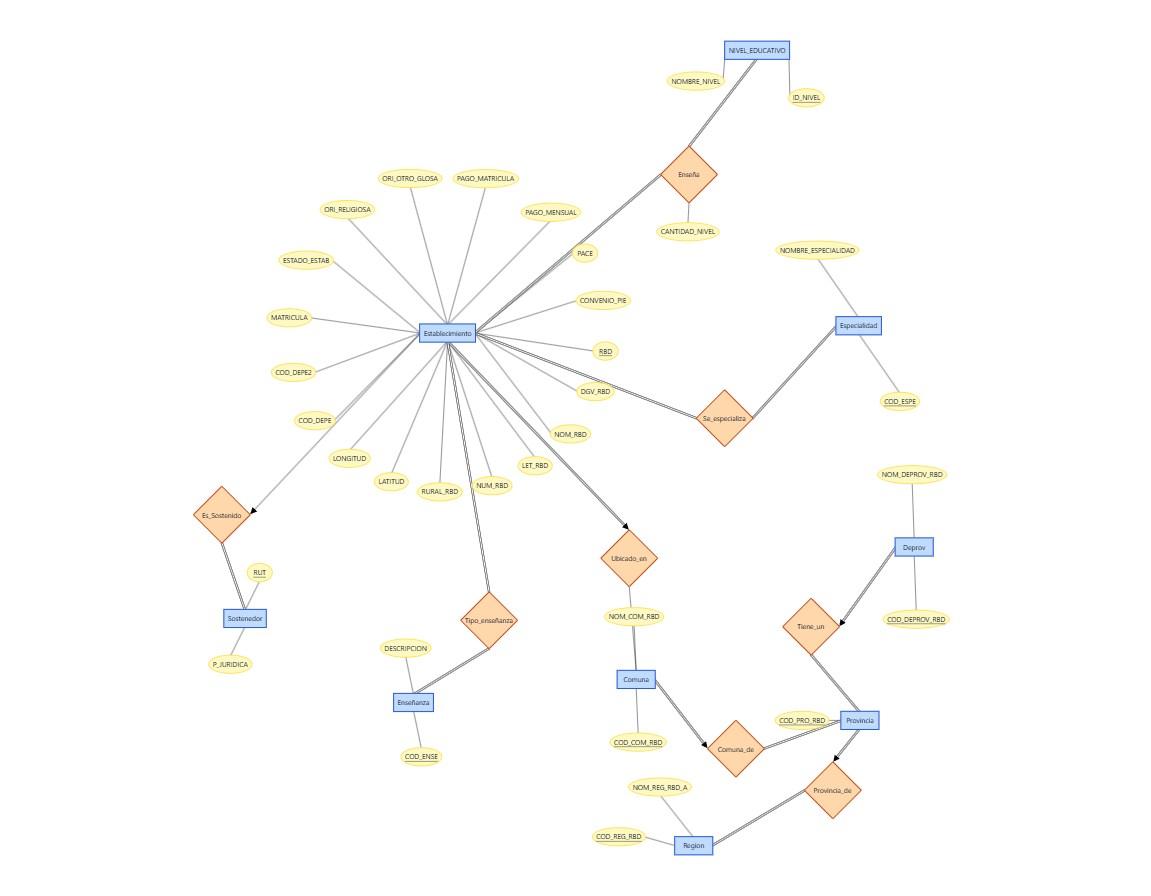

---

In [2]:
## Configuraciones

### Librerias
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os 
import warnings
warnings.filterwarnings('ignore')

### Directorio 

path = 'C:/Users/bruno/OneDrive/Documentos/Base de datos/PROYECTO BBDD/'
os.chdir(path)

### Conexión

conn = psycopg2.connect(
    host='localhost',
    port=5432,
    user='postgres',
    password='admin1234',
    database='ESTABLECIMIENTOS_EDUCACIONALES',
    options='-c search_path=educacion'
)
### Configuración de gráficos
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
})
PALETTE = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2"]

### Pregunta 1

 ¿Los establecimientos que imparten educación técnico-profesional están distribuidos equitativamente entre regiones, o se concentran en la región metropolitana?

  region  n_estab_tp  pct_del_total_tp  ranking
0     RM         290             29.80        1
1  VALPO          97              9.97        2
2  ARAUC          81              8.32        3
3   BBIO          79              8.12        4
4  MAULE          71              7.30        5
-------------------------------------------------------------------------------------------------


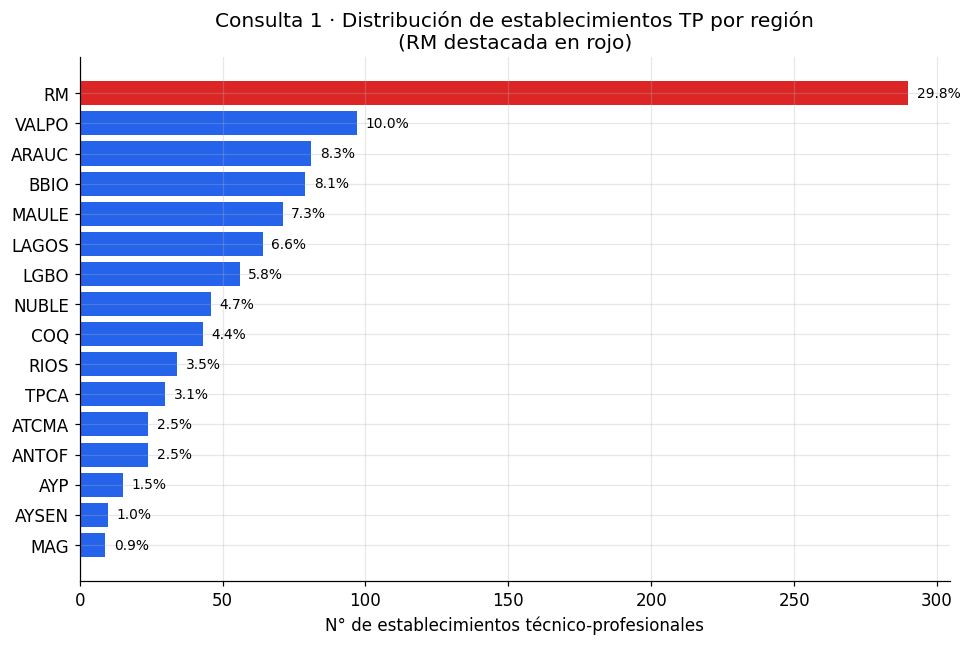

La RM concentra el 29.8% de la oferta TP nacional (ranking #1).


In [3]:
Q1 = '''
WITH establecimientos_tp AS (
    SELECT DISTINCT en.e_RBD
    FROM establecimiento_nivel en
    WHERE en.n_ID_NIVEL IN (7, 8)
    UNION
    SELECT DISTINCT ee.e_RBD
    FROM establecimiento_ensenanza ee
    WHERE ee.en_COD_ENSE IN (410,460,461,463, 510,560,561,563,
                             610,660,661,663, 710,760,761,763,
                             810,860,863)
)
SELECT
    r.NOM_REG_RBD                                        AS region,
    COUNT(DISTINCT etp.e_RBD)                            AS n_estab_tp,
    ROUND(100.0 * COUNT(DISTINCT etp.e_RBD)
          / NULLIF(SUM(COUNT(DISTINCT etp.e_RBD)) OVER (), 0), 2) AS pct_del_total_tp,
    RANK() OVER (ORDER BY COUNT(DISTINCT etp.e_RBD) DESC)         AS ranking
FROM region r
LEFT JOIN provincia p        ON p.r_COD_REG_RBD = r.COD_REG_RBD
LEFT JOIN comuna c           ON c.p_COD_PRO_RBD = p.COD_PRO_RBD
LEFT JOIN establecimiento e  ON e.c_COD_COM_RBD = c.COD_COM_RBD
LEFT JOIN establecimientos_tp etp ON etp.e_RBD = e.RBD
GROUP BY r.NOM_REG_RBD
ORDER BY n_estab_tp DESC;
'''
df1 = pd.read_sql_query(Q1, conn)
print(df1.head())
print('-------------------------------------------------------------------------------------------------')
fig, ax = plt.subplots(figsize=(9, 6))
d = df1.sort_values("n_estab_tp")
colors = ["#dc2626" if "RM" in r else "#2563eb" for r in d["region"]]
bars = ax.barh(d["region"], d["n_estab_tp"], color=colors)
for b, p in zip(bars, d["pct_del_total_tp"]):
    ax.text(b.get_width()+3, b.get_y()+b.get_height()/2, f"{p:.1f}%",
            va="center", fontsize=9)
ax.set_xlabel("N° de establecimientos técnico-profesionales")
ax.set_title("Consulta 1 · Distribución de establecimientos TP por región\n(RM destacada en rojo)")
plt.tight_layout()
plt.savefig('graficos/Consulta1.png', dpi = 300)
plt.show()

rm = df1[df1["region"].str.contains("RM")]
if not rm.empty:
    print(f"La RM concentra el {rm['pct_del_total_tp'].iloc[0]:.1f}% de la oferta TP nacional (ranking #{int(rm['ranking'].iloc[0])}).")

### Pregunta 2

¿En qué comuna de RM se concentran los establecimientos educacionales con un pago de mensualidad de más de $100.000?

   nom_com_rbd  estab_caros  ranking
0   LAS CONDES           54        1
1  PROVIDENCIA           34        2
2        ÑUÑOA           29        3
3   LA FLORIDA           28        4
4     LA REINA           26        5
--------------------------------------------------------------------------------------------


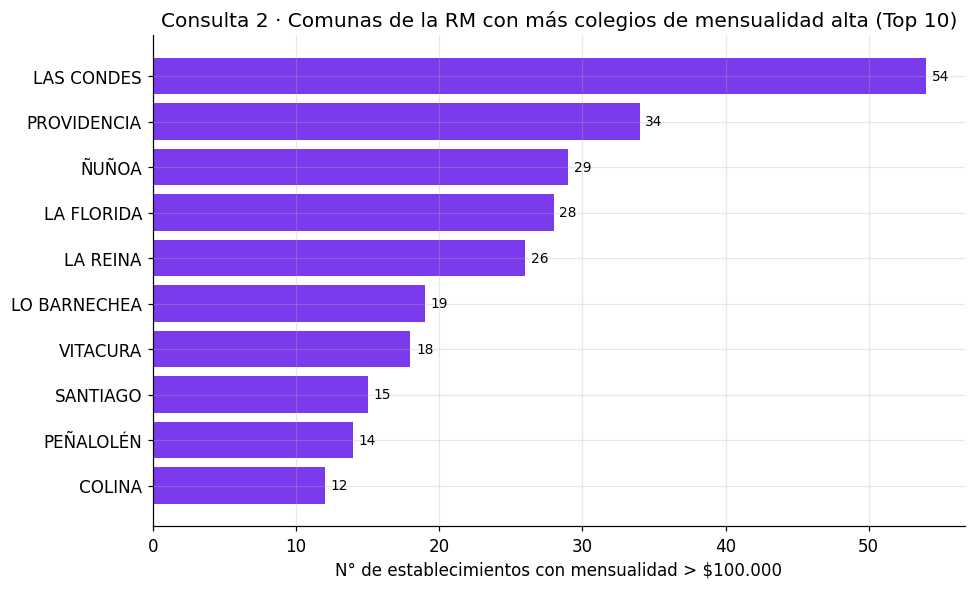

Comuna líder: LAS CONDES


In [4]:
Q2 = """
SELECT
    c.nom_com_rbd,
    COUNT(*) AS estab_caros,
    RANK() OVER (ORDER BY COUNT(*) DESC) AS ranking
FROM establecimiento e
JOIN comuna c    ON c.cod_com_rbd = e.c_cod_com_rbd
JOIN provincia p ON p.cod_pro_rbd = c.p_cod_pro_rbd
JOIN region r    ON r.cod_reg_rbd = p.r_cod_reg_rbd
WHERE r.cod_reg_rbd = 13
  AND e.pago_mensual = 'MAS DE $100.000'
GROUP BY c.nom_com_rbd
ORDER BY estab_caros DESC;
"""
df2 = pd.read_sql_query(Q2, conn)
print(df2.head())
print('--------------------------------------------------------------------------------------------')
fig, ax = plt.subplots(figsize=(9, 5.5))
top = df2.head(10).sort_values("estab_caros")
ax.barh(top["nom_com_rbd"], top["estab_caros"], color="#7c3aed")
for i,(v) in enumerate(top["estab_caros"]):
    ax.text(v+0.4, i, str(int(v)), va="center", fontsize=9)
ax.set_xlabel("N° de establecimientos con mensualidad > $100.000")
ax.set_title("Consulta 2 · Comunas de la RM con más colegios de mensualidad alta (Top 10)")
plt.tight_layout()
plt.savefig('graficos/Consulta2.png', dpi = 300)
plt.show()
print("Comuna líder:", df2.iloc[0]['nom_com_rbd'])

### Pregunta 2 - Parametrización

¿En qué comuna de la región ```X``` se concentran los establecimientos educacionales con un pago de mensualidad ```Y```?

' OR '1'='1

13 ;DROP TABLE establecimiento; --

Tramos de mensualidad válidos:  ['GRATUITO', '$1.000 A $10.000', '$10.001 A $25.000', '$25.001 A $50.000', '$50.001 A $100.000', 'MAS DE $100.000']


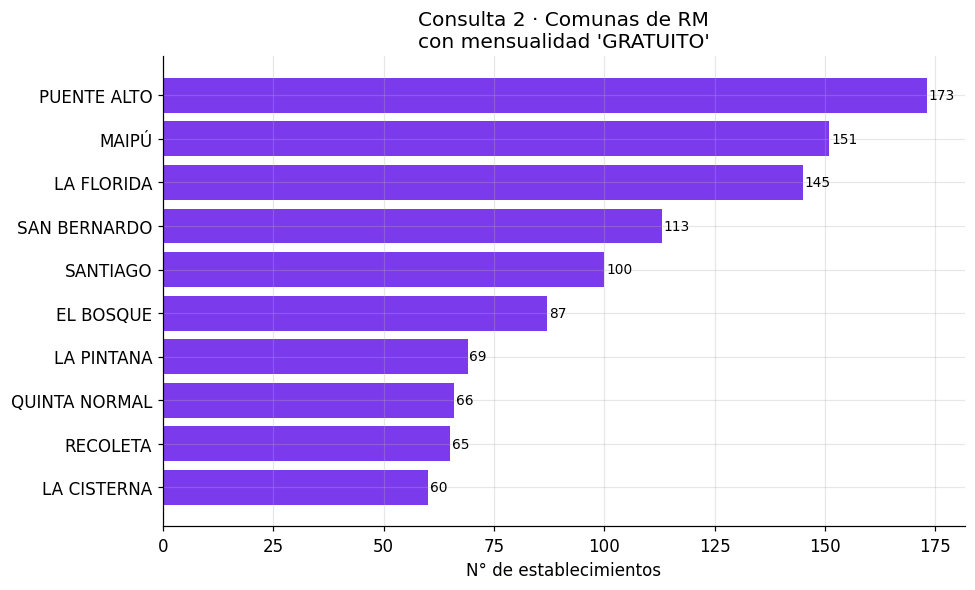

Comuna líder: PUENTE ALTO (173 establecimientos)


In [11]:
TRAMOS_VALIDOS = [
    "GRATUITO", "$1.000 A $10.000", "$10.001 A $25.000",
    "$25.001 A $50.000", "$50.001 A $100.000", "MAS DE $100.000"
]

region_id = str(input('Ingrese código de región (1 - 16): '))
print('Tramos de mensualidad válidos: ',TRAMOS_VALIDOS)
tramo_pago = str(input('Ingrese tramo de mensualidad a evaluar: '))

try:
    region_id = int(region_id)                 # fuerza tipo entero
except (TypeError, ValueError):
    raise ValueError("El código de región debe ser un entero entre 1 y 16.")
if not (1 <= region_id <= 16):
    raise ValueError("Código de región fuera de rango (1 a 16).")

tramo_pago = tramo_pago.strip().upper()        # normaliza el input
if tramo_pago not in TRAMOS_VALIDOS:
    raise ValueError(f"Tramo inválido. Opciones válidas: {TRAMOS_VALIDOS}")

Q2_P = """
SELECT
    r.nom_reg_rbd                        AS region,
    c.nom_com_rbd                        AS comuna,
    COUNT(*)                             AS n_establecimientos,
    RANK() OVER (ORDER BY COUNT(*) DESC) AS ranking
FROM establecimiento e
JOIN comuna c    ON c.cod_com_rbd = e.c_cod_com_rbd
JOIN provincia p ON p.cod_pro_rbd = c.p_cod_pro_rbd
JOIN region r    ON r.cod_reg_rbd = p.r_cod_reg_rbd
WHERE r.cod_reg_rbd = %(region_id)s          -- parámetro vinculado
  AND e.pago_mensual = %(tramo_pago)s        -- parámetro vinculado
GROUP BY r.nom_reg_rbd, c.nom_com_rbd
ORDER BY n_establecimientos DESC;
"""
conn.rollback()
df2_p = pd.read_sql_query(Q2_P, conn, params={"region_id": region_id, "tramo_pago": tramo_pago})
df2_p.head()

if df2_p.empty:
    print(f"No se encontraron establecimientos en la región {region_id} "
          f"con tramo '{tramo_pago}'.")
else:
    nombre_region = df2_p["region"].iloc[0]     # nombre legible de la región

    fig, ax = plt.subplots(figsize=(9, 5.5))
    top = df2_p.head(10).sort_values("n_establecimientos")
    ax.barh(top["comuna"], top["n_establecimientos"], color="#7c3aed")
    for i, v in enumerate(top["n_establecimientos"]):
        ax.text(v + 0.4, i, str(int(v)), va="center", fontsize=9)
    ax.set_xlabel("N° de establecimientos")
    ax.set_title(f"Consulta 2 · Comunas de {nombre_region}\n"
                 f"con mensualidad '{tramo_pago}'")
    plt.tight_layout()
    plt.show()

    print("Comuna líder:", df2_p.iloc[0]["comuna"],
          f"({int(df2_p.iloc[0]['n_establecimientos'])} establecimientos)")


### Pregunta 3

¿A medida que un sostenedor concentra más establecimientos, tiende a cobrar
más o menos mensualidad a las familias?

  tramo_concentracion      pago_mensual     n
0                 20+  $1.000 A $10.000     1
1                 2-5   MAS DE $100.000   124
2                 2-5          GRATUITO  1095
3                   1          GRATUITO  3828
4                 2-5  $1.000 A $10.000     3
---------------------------------------------------------------------------------------


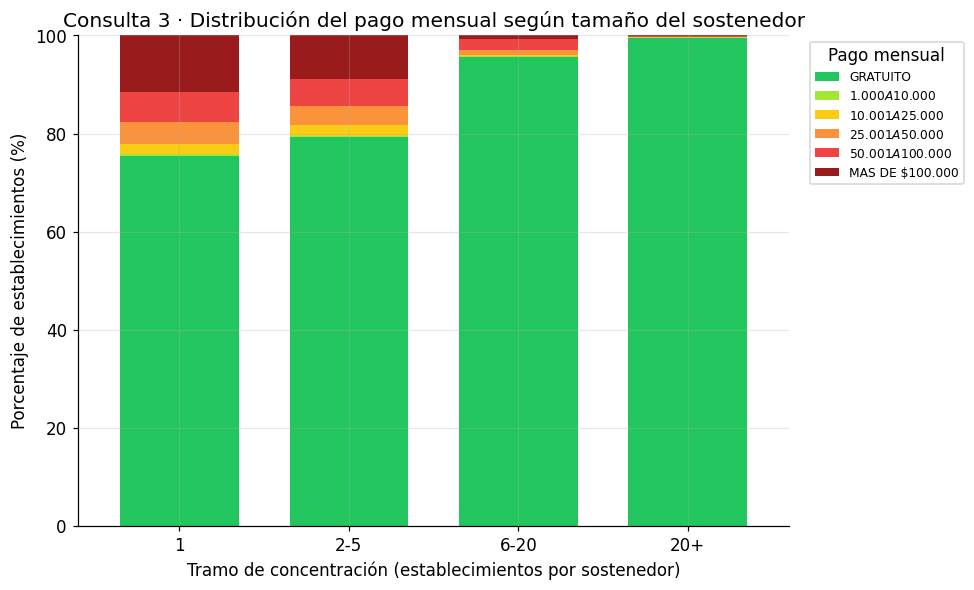

In [9]:
Q3 = """
WITH sost AS (
    SELECT es.s_rut, COUNT(*) AS n_estab
    FROM establecimiento_sostenedor es
    GROUP BY es.s_rut
),
base AS (
    SELECT
        CASE WHEN s.n_estab = 1 THEN '1'
             WHEN s.n_estab BETWEEN 2 AND 5  THEN '2-5'
             WHEN s.n_estab BETWEEN 6 AND 20 THEN '6-20'
             ELSE '20+' END AS tramo_concentracion,
        e.pago_mensual
    FROM establecimiento e
    JOIN establecimiento_sostenedor es ON es.e_rbd = e.rbd
    JOIN sost s ON s.s_rut = es.s_rut
    WHERE e.pago_mensual IS NOT NULL
      AND e.pago_mensual <> 'SIN INFORMACION'
)
SELECT tramo_concentracion, pago_mensual, COUNT(*) AS n
FROM base
GROUP BY tramo_concentracion, pago_mensual;
"""
df3 = pd.read_sql_query(Q3, conn)
print(df3.head())
print('---------------------------------------------------------------------------------------')
orden_tramos = ["1", "2-5", "6-20", "20+"]
orden_pago = ["GRATUITO", "$1.000 A $10.000", "$10.001 A $25.000",
              "$25.001 A $50.000", "$50.001 A $100.000", "MAS DE $100.000"]

tabla = (df3.pivot(index="tramo_concentracion", columns="pago_mensual", values="n")
              .reindex(orden_tramos)
              .reindex(columns=orden_pago)
              .fillna(0))

prop = tabla.div(tabla.sum(axis=1), axis=0) * 100  # porcentajes por fila

# Paleta secuencial: de verde (gratuito) a rojo oscuro (más caro)
colores = ["#22c55e", "#a3e635", "#facc15", "#fb923c", "#ef4444", "#991b1b"]

fig, ax = plt.subplots(figsize=(9, 5.5))
prop.plot(kind="bar", stacked=True, color=colores, ax=ax, width=0.7)

ax.set_ylabel("Porcentaje de establecimientos (%)")
ax.set_xlabel("Tramo de concentración (establecimientos por sostenedor)")
ax.set_title("Consulta 3 · Distribución del pago mensual según tamaño del sostenedor")
ax.set_xticklabels(orden_tramos, rotation=0)
ax.legend(title="Pago mensual", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('graficos/Consulta3.png', dpi=300, bbox_inches='tight')
plt.show()

### Pregunta 4

¿Los establecimientos con programa PACE tienden a tener mayor matrícula en enseñanza media humanista-científica o en técnico-profesional?

   n_estab_pace  matricula_hc  matricula_tp
0           650        153269        120491
---------------------------------------------------------------------------------------


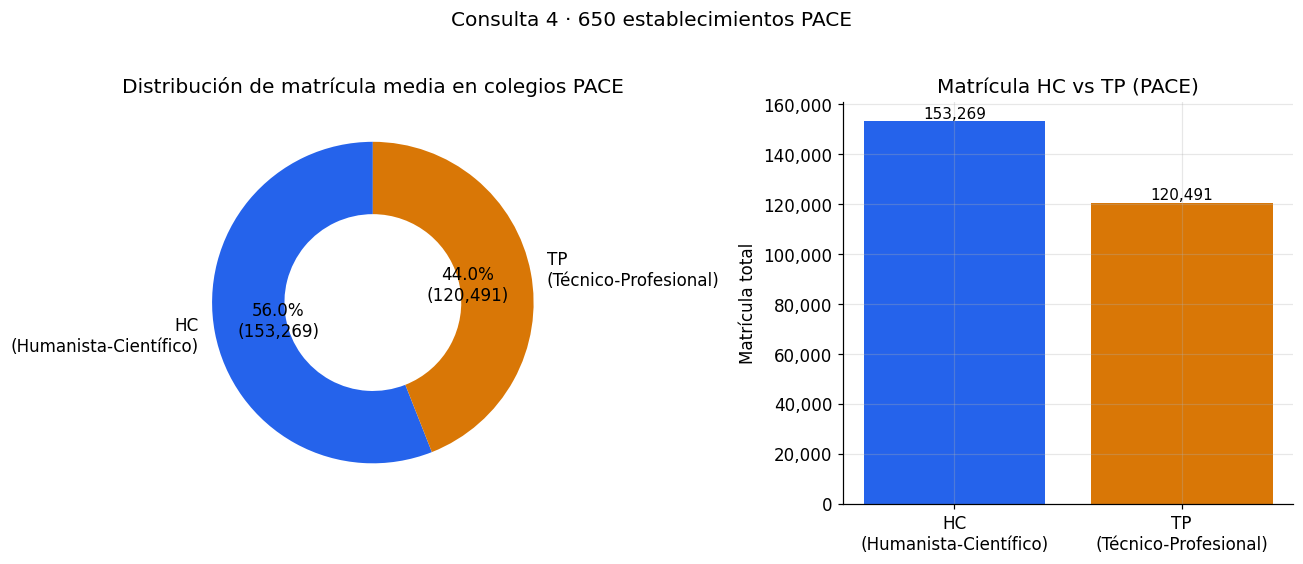

In [11]:
Q4 = """
SELECT
    COUNT(DISTINCT e.rbd)                                              AS n_estab_pace,
    SUM(en.cantidad_nivel) FILTER (WHERE en.n_id_nivel IN (5,6))       AS matricula_hc,
    SUM(en.cantidad_nivel) FILTER (WHERE en.n_id_nivel IN (7,8))       AS matricula_tp
FROM establecimiento e
JOIN establecimiento_nivel en ON en.e_rbd = e.rbd
WHERE e.pace = TRUE
  AND en.n_id_nivel IN (5,6,7,8);
"""
df4 = pd.read_sql_query(Q4, conn)
print(df4.head())
print('---------------------------------------------------------------------------------------')
vals = [int(df4['matricula_hc'].iloc[0]), int(df4['matricula_tp'].iloc[0])]
labels = ["HC\n(Humanista-Científico)", "TP\n(Técnico-Profesional)"]
fig, (axp, axb) = plt.subplots(1, 2, figsize=(12, 5))
axp.pie(vals, labels=labels, autopct=lambda p: f"{p:.1f}%\n({int(p*sum(vals)/100):,})",
        colors=["#2563eb","#d97706"], startangle=90, wedgeprops=dict(width=0.45))
axp.set_title("Distribución de matrícula media en colegios PACE")
axb.bar(labels, vals, color=["#2563eb","#d97706"])
for i,v in enumerate(vals): axb.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)
axb.set_ylabel("Matrícula total")
axb.set_title("Matrícula HC vs TP (PACE)")
axb.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
plt.suptitle(f"Consulta 4 · {int(df4['n_estab_pace'].iloc[0])} establecimientos PACE", y=1.02)
plt.tight_layout()
plt.savefig('graficos/Consulta4.png', dpi = 300)
plt.show()

### Pregunta 5

¿La proporción de establecimientos de orientación evangélica versus católica varía según la ruralidad del establecimiento?

  ruralidad  n_catolica  n_evangelica  pct_evangelica_entre_religiosos
0     Rural        1409           273                            16.23
1    Urbano        1780           250                            12.32
-----------------------------------------------------------------------------------


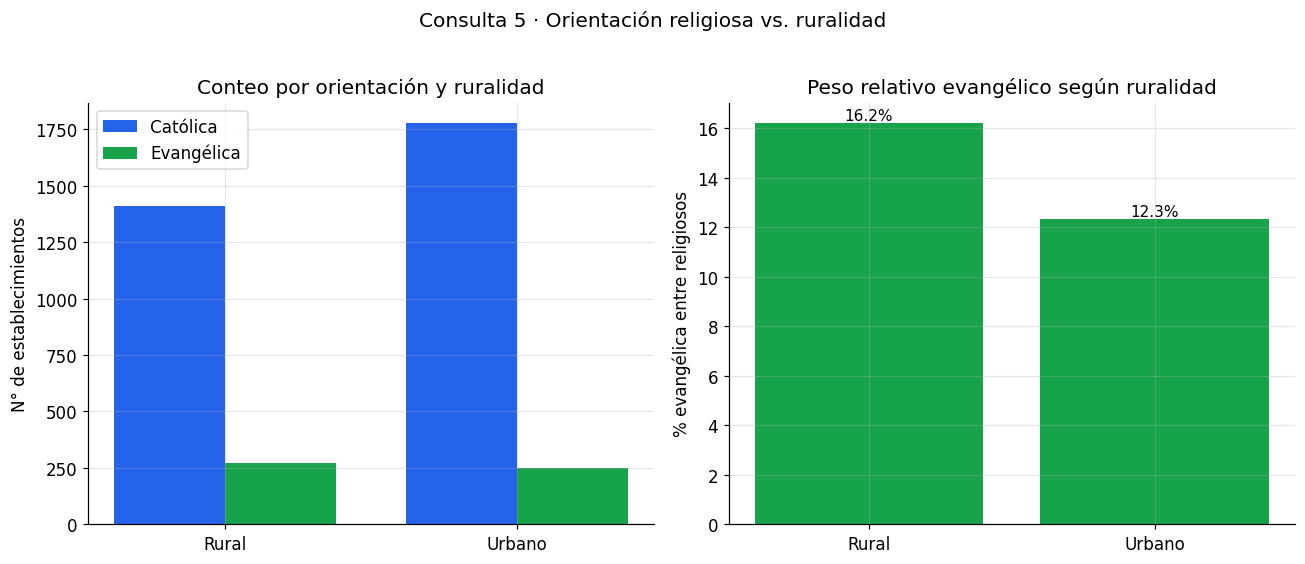

In [ ]:
Q5 = """
SELECT
    CASE WHEN e.rural_rbd = 1 THEN 'Rural' ELSE 'Urbano' END   AS ruralidad,
    COUNT(*) FILTER (WHERE e.ori_religiosa = '2')              AS n_catolica,
    COUNT(*) FILTER (WHERE e.ori_religiosa = '3')              AS n_evangelica,
    ROUND(100.0 * COUNT(*) FILTER (WHERE e.ori_religiosa = '3')
          / NULLIF(COUNT(*) FILTER (WHERE e.ori_religiosa IN ('2','3')),0), 2)
                                                               AS pct_evangelica_entre_religiosos
FROM establecimiento e
WHERE e.ori_religiosa IN ('2','3')
GROUP BY 1 ORDER BY ruralidad;
"""
df5 = pd.read_sql_query(Q5, conn)
print(df5.head())
print('-----------------------------------------------------------------------------------')
fig, (axs, axr) = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(df5))
w = 0.38
axs.bar(x-w/2, df5["n_catolica"], w, label="Católica", color="#2563eb")
axs.bar(x+w/2, df5["n_evangelica"], w, label="Evangélica", color="#16a34a")
axs.set_xticks(x)
axs.set_xticklabels(df5["ruralidad"])
axs.legend()
axs.set_ylabel("N° de establecimientos")
axs.set_title("Conteo por orientación y ruralidad")
axr.bar(df5["ruralidad"], df5["pct_evangelica_entre_religiosos"], color="#16a34a")
for i,v in enumerate(df5["pct_evangelica_entre_religiosos"]):
    axr.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=10)
axr.set_ylabel("% evangélica entre religiosos")
axr.set_title("Peso relativo evangélico según ruralidad")
plt.suptitle("Consulta 5 · Orientación religiosa vs. ruralidad", y=1.02)
plt.tight_layout()
plt.savefig('graficos/Consulta5.png', dpi = 300)
plt.show()

### Pregunta 6

¿Los establecimientos que ofrecen tanto enseñanza media jóvenes como enseñanza media adulta en la misma área (por ejemplo humanista-científica en jóvenes y humanista-científica en adultos) tienden a tener mayor matrícula total que los que solo ofrecen una modalidad?

                               grupo  n_establecimientos  matricula_promedio  \
0  Ofrece misma area jovenes+adultos                 232               695.3   
1                 Solo una modalidad               16536               204.4   

   mediana_matricula  min_mat  max_mat  
0              587.0       51     2931  
1               47.0        0     3923  
--------------------------------------------------------------------


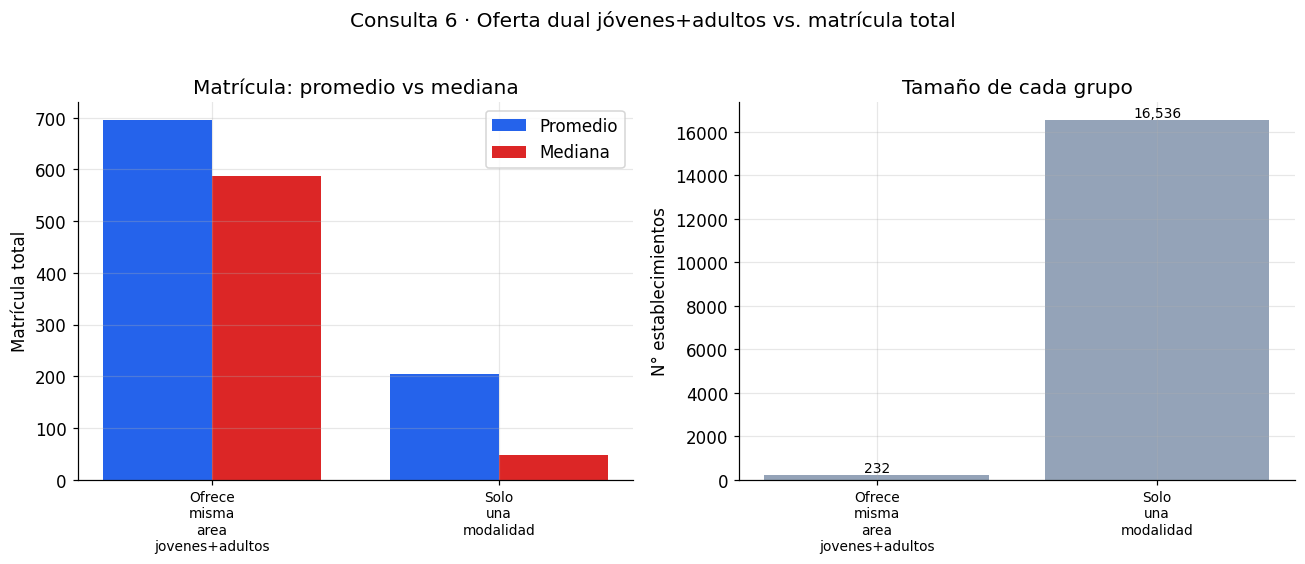

In [13]:
Q6 = """
WITH clasificacion AS (
    SELECT e.rbd, e.mat_total,
        (EXISTS (SELECT 1 FROM establecimiento_ensenanza ee
                 WHERE ee.e_rbd=e.rbd AND ee.en_cod_ense=310)
         AND EXISTS (SELECT 1 FROM establecimiento_ensenanza ee
                 WHERE ee.e_rbd=e.rbd AND ee.en_cod_ense IN (360,361,362,363))) AS dual_hc,
        (EXISTS (SELECT 1 FROM establecimiento_ensenanza ee
                 WHERE ee.e_rbd=e.rbd AND ee.en_cod_ense IN (410,510,610,710,810,910))
         AND EXISTS (SELECT 1 FROM establecimiento_ensenanza ee
                 WHERE ee.e_rbd=e.rbd AND ee.en_cod_ense IN
                 (460,461,463,560,561,563,660,661,663,760,761,763,860,863))) AS dual_tp
    FROM establecimiento e
),
grupos AS (
    SELECT rbd, mat_total,
        CASE WHEN dual_hc OR dual_tp
             THEN 'Ofrece misma area jovenes+adultos'
             ELSE 'Solo una modalidad' END AS grupo
    FROM clasificacion
)
SELECT grupo,
    COUNT(*) AS n_establecimientos,
    ROUND(AVG(mat_total),1) AS matricula_promedio,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY mat_total) AS mediana_matricula,
    MIN(mat_total) AS min_mat, MAX(mat_total) AS max_mat
FROM grupos WHERE mat_total IS NOT NULL
GROUP BY grupo ORDER BY matricula_promedio DESC;
"""
df6 = pd.read_sql_query(Q6, conn)
print(df6.head())
print('--------------------------------------------------------------------')
fig, (axm, axn) = plt.subplots(1, 2, figsize=(12, 5))
g = [s.replace(" ", "\n") for s in df6["grupo"]]
x = np.arange(len(df6)); w = 0.38
axm.bar(x-w/2, df6["matricula_promedio"], w, label="Promedio", color="#2563eb")
axm.bar(x+w/2, df6["mediana_matricula"], w, label="Mediana", color="#dc2626")
axm.set_xticks(x); axm.set_xticklabels(g, fontsize=9)
axm.legend()
axm.set_ylabel("Matrícula total")
axm.set_title("Matrícula: promedio vs mediana")
axn.bar(x, df6["n_establecimientos"], color="#94a3b8")
for i,v in enumerate(df6["n_establecimientos"]):
    axn.text(i, v, f"{int(v):,}", ha="center", va="bottom", fontsize=9)
axn.set_xticks(x)
axn.set_xticklabels(g, fontsize=9)
axn.set_ylabel("N° establecimientos")
axn.set_title("Tamaño de cada grupo")
plt.suptitle("Consulta 6 · Oferta dual jóvenes+adultos vs. matrícula total", y=1.02)
plt.tight_layout()
plt.savefig('graficos/Consulta6.png', dpi = 300)
plt.show()

## Conclusiones generales

| # | Pregunta | Hallazgo principal |
|---|----------|--------------------|
| 1 | Distribución TP | Fuerte concentración en la **RM**; distribución territorial desigual. |
| 2 | Colegios caros RM | Concentrados en el **nororiente** (Las Condes, Vitacura, Providencia). |
| 3 | Sostenedores vs pago | Relación **no monótona**; los grandes (públicos) cobran menos. |
| 4 | PACE HC vs TP | Predominio de matrícula **humanista-científica**. |
| 5 | Religión vs ruralidad | Católica domina; peso **evangélico mayor en zonas rurales**. |
| 6 | Oferta dual | Los duales tienen **mayor matrícula total**, pero son minoría. |

El análisis muestra que la oferta educativa chilena está marcada por la **centralización territorial** y la
**segregación socioeconómica**, y que la estructura administrativa (público vs. privado) explica buena parte de las
diferencias de cobro. La consulta parametrizable permite explorar interactivamente esta desigualdad por región y
tramo de pago, de forma segura frente a inyección SQL.
